In [1]:
from snAPI.Main import *
import time
#from matplotlib.animation import FuncAnimation
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt

# Connect to Multiharp
# Need to shut down the API to connect correctly
sn = snAPI()
sn.getDevice()
sn.initDevice(MeasMode.T2)

# setInputEdgeTrig(channel,trig(mV),edge)
# 0 = falling, 1 = rising
sn.device.setInputEdgeTrig(0,-300,0) # CH1: 0; CH2:1, etc.
sn.device.setInputEdgeTrig(1,-300,0)  # Need to double check

sn.device.setInputChannelOffset(0, int(0.5 * 1000))
sn.device.setInputChannelOffset(1, int(0 * 1000))

CH1 = 1
CH2 = 2

COINCIDENCE_WINDOW = 20000    # ps = 20 ns
HISTORY = 60                 # show last 30 s
NUM_BINS = 300               # 0.1 s/bin

CC12_ID = sn.manipulators.coincidence(
    [CH1, CH2],
    windowTime=COINCIDENCE_WINDOW,
    mode=CoincidenceMode.CountOnce,
    keepChannels=True
)

sn.timeTrace.setNumBins(NUM_BINS)
sn.timeTrace.setHistorySize(HISTORY)

#print(sn.timeTrace.numBins)
print(sn.deviceConfig.get("NumChans"))
print(sn.deviceConfig.get("ID"))
print(sn.dll.getNumAllChans(sn.timeTrace.ID))

8
1054720
10


Peak delay = -0.25 ns


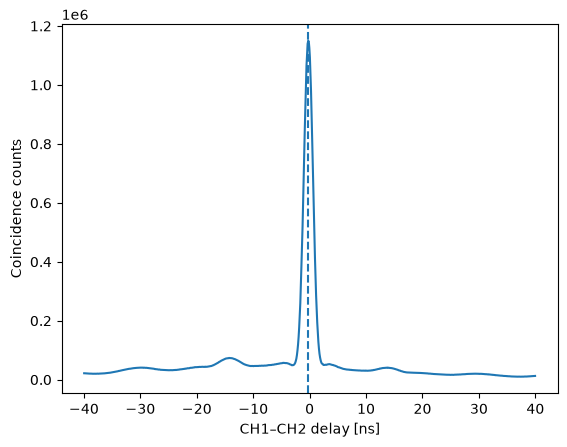

In [4]:
# CH1-CH2 correlation to find delay
sn.correlation.setG2Parameters(
    1, 2,
    windowSize=40000,   # 40 ns
    binWidth=100,       # 0.1 ns
    normalization=False
)

sn.correlation.measure(
    acqTime=5000,       # 5 s
    waitFinished=True
)

cc, bins = sn.correlation.getG2Data()

delay_ns = np.array(bins) * 1e9
delay0 = delay_ns[np.argmax(cc)]

print(f"Peak delay = {delay0:.2f} ns")

plt.plot(delay_ns, cc)
plt.axvline(delay0, ls="--")
plt.xlabel("CH1–CH2 delay [ns]")
plt.ylabel("Coincidence counts")
plt.show()

In [2]:
%matplotlib qt

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(12, 9),
    sharex=True)

line1, = ax1.plot([], [], label="CH1")
line2, = ax1.plot([], [], label="CH2")
linesum12, = ax1.plot([], [], label="SUM1+2")
ax1.set_ylabel("Single count rate [counts/s]")
ax1.legend()
ax1.grid(True)

linec, = ax2.plot([], [], label="CC12")

ax2.set_ylabel("Coincidence count rate [counts/s]")
#ax.set_title("Multiharp counts plot")
ax2.legend()
ax2.grid(True)

linep, = ax3.plot([], [], label="CC_coeff")

ax3.set_xlabel("Time [s]")
ax2.set_ylabel("Coincidence Coefficicnet")
#ax.set_title("Multiharp counts plot")
ax3.legend()
ax3.grid(True)

# live numerical readout
status_text = ax1.text(
    0.02, 0.97,
    "",
    transform=ax1.transAxes,
    va="top"
)

# IMPORTANT: actually create/show the external window
plt.show(block=False)
plt.pause(0.1)

sn.timeTrace.measure(
    acqTime=0,
    waitFinished=False,
    savePTU=False
)

try:
    while True:

        counts, times = sn.timeTrace.getData()

        if len(times) > 0:

            ch1 = counts[CH1]
            ch2 = counts[CH2]
            chsum12 = ch1 + ch2
            cc12 = counts[CC12_ID]
            ccoeff = cc12/np.sqrt(ch1*ch2)

            # numerical display
            status_text.set_text(
                f"CH1: {ch1[-1]:,.0f} cps \n   "
                f"CH2: {ch2[-1]:,.0f} cps \n   "
                f"CC12: {cc12[-1]:,.1f} cps"
            )

            # traces
            line1.set_data(times, ch1)
            line2.set_data(times, ch2)
            linesum12.set_data(times, chsum12)
            linec.set_data(times, cc12)
            linep.set_data(times, ccoeff)

            ax1.relim()
            ax1.autoscale_view()
            ax2.relim()
            ax2.autoscale_view()
            ax3.relim()
            ax3.autoscale_view()

            fig.canvas.draw_idle()

        # processes Qt GUI events AND gives acquisition loop time
        plt.pause(0.1)

except KeyboardInterrupt:
    sn.timeTrace.stopMeasure()
    print("Stopped")

C:\Users\SERF321\AppData\Local\Temp\ipykernel_36588\1870986726.py:59: RuntimeWarning: invalid value encountered in divide
  ccoeff = cc12/np.sqrt(ch1*ch2)


Stopped


#### Function generator phase control

In [ ]:
import pyvisa

rm = pyvisa.ResourceManager()
awg = rm.open_resource("USB0::0x0957::0x5707::MY53802358::INSTR")

awg.timeout = 5000

print(awg.query("*IDN?"))

awg.write("*CLS")

awg.write("SOUR1:FUNC PULS")
awg.write("SOUR1:FREQ 10E6")
awg.write("SOUR1:FUNC:PULS:WIDT 5E-9")

awg.write("SOUR1:VOLT 1.7")      # 1 Vpp
awg.write("SOUR1:VOLT:OFFS 0") # 0 V offset

awg.write("UNIT:ANGL SEC")
awg.write("SOUR1:PHAS 0E-9")   # 5 ns      # phase in ns

awg.write("OUTP1 ON")

print(awg.query("SYST:ERR?"))

In [ ]:
awg.write("SOUR1:VOLT 1.7")

sn.timeTrace.setHistorySize(1)   # 1 second
sn.timeTrace.setNumBins(10)      # 10 bins, each 0.1 s

phase_ns = np.arange(-10, 80, 0.2)   # 0 -> 100 ns, 0.2 ns step

ch1_list = []
ch2_list = []
cc12_list = []
cc_coeff_list = []

for p_ns in phase_ns:

    awg.write(f"SOUR1:PHAS {p_ns * 1e-9}")
    time.sleep(0.1)

    sn.timeTrace.measure(
        acqTime=1000,          # ms
        waitFinished=True,
        savePTU=False
    )

    counts, times = sn.timeTrace.getData()

    ch1 = np.mean(counts[CH1])
    ch2 = np.mean(counts[CH2])
    cc12 = np.mean(counts[CC12_ID])

    cc_coeff = cc12 / np.sqrt(ch1 * ch2)

    ch1_list.append(ch1)
    ch2_list.append(ch2)
    cc12_list.append(cc12)
    cc_coeff_list.append(cc_coeff)

    print(
        f"{p_ns:5.1f} ns | "
        f"CH1 = {ch1:,.0f} cps | "
        f"CH2 = {ch2:,.0f} cps | "
        f"CC12 = {cc12:,.0f} cps | "
        f"coeff = {cc_coeff:.4f}"
    )

ch1_list = np.array(ch1_list)
ch2_list = np.array(ch2_list)
cc12_list = np.array(cc12_list)
cc_coeff_list = np.array(cc_coeff_list)

In [ ]:
len(cc_coeff_list)

In [ ]:
%matplotlib inline
min_val = np.min(cc_coeff_list[30*5:60*5])
max_val= np.max(cc_coeff_list)
final_val= min_val/max_val
print(max_val,min_val)
print(final_val)


fig, ax = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

ax[0].plot(phase_ns, ch1_list, label="CH1")
ax[0].plot(phase_ns, ch2_list, label="CH2")
ax[0].plot(phase_ns, ch1_list + ch2_list, label="SUM1+2")
ax[0].set_ylabel("Singles [cps]")
ax[0].legend()
ax[0].grid()

ax[1].plot(phase_ns, cc12_list)
ax[1].set_ylabel("CC12 [cps]")
ax[1].grid()

ax[2].plot(phase_ns, cc_coeff_list)
ax[2].set_ylabel("CC coefficient")
ax[2].set_xlabel("AWG phase delay [ns]")
ax[2].grid('minor')

plt.suptitle('1.7v_ccwin20ns_pw5ns_0814')
plt.tight_layout()
plt.savefig('1.7v_ccwin20ns_pw5ns_0814.png',dpi=300)
plt.show()

In [3]:
sn.closeDevice()
sn.exitAPI()

print("MultiHarp released")

MultiHarp released


In [ ]:
# run continuously and display counts in real time

status = display("", display_id=True)

sn.timeTrace.measure(
    acqTime=0,
    waitFinished=False,
    savePTU=False
)

try:
    while True:
        counts, times = sn.timeTrace.getData()
        ch1 = counts[CH1]
        ch2 = counts[CH2]
        cc12 = counts[CC12_ID]

        if len(times) > 0:
            status.update(
                f"Ch1: {ch1[-1]:,.0f} cps   |   "
                f"Ch2: {ch2[-1]:,.0f} cps   |   "
                f"Coinc: {cc12[-1]:,.1f} cps"
                )
        

except KeyboardInterrupt:
    sn.timeTrace.stopMeasure()